In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import random
import copy

# Transformers and SegFormer
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from transformers import SegformerImageProcessor

# Data augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cuda


In [2]:
images_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/kaggle/images"
masks_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/kaggle/masks"

# path to save models, history and results
SAVE_DIR = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/kaggle/SegFormer"
os.makedirs(SAVE_DIR, exist_ok=True)

Dataset

In [3]:
class FireDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path = masks_path
        self.transform = transform
        self.images = sorted(os.listdir(images_path))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_path, img_name)
        mask_name = img_name.replace("_rgb", "_gt")
        mask_path = os.path.join(self.masks_path, mask_name)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))

        mask = (mask > 0).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        if image.shape[1] != 256 or image.shape[2] != 256:
            image = torch.nn.functional.interpolate(
                image.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
            ).squeeze(0)

        if mask.shape[1] != 256 or mask.shape[2] != 256:
            mask = torch.nn.functional.interpolate(
                mask.unsqueeze(0), size=(256, 256), mode="nearest"
            ).squeeze(0)

        return image, mask

Data Augmentation

In [4]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Resize(256, 256),
    A.HueSaturationValue(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

Data Splits

In [5]:
def create_data_splits(images_path, masks_path, train_transform, val_transform, data_percentage=1.0):
    """
    Create data splits with specific percentage of total dataset.

    Args:
        images_path: Path to images
        masks_path: Path to masks
        train_transform: Training transformations
        val_transform: Validation/test transformations
        data_percentage: Data split percentages (0.25, 0.5, 1.0)

    Returns:
        train_dataset, val_dataset, test_dataset
    """
    # Complete dataset
    total_size = len(FireDataset(images_path, masks_path))

    # Get size based on the percentage
    used_size = int(total_size * data_percentage)

    # Splits: 70% train, 15% val, 15% test
    train_size = int(0.7 * used_size)
    val_size = int(0.15 * used_size)
    test_size = used_size - train_size - val_size

    print(f"\nUsing {data_percentage*100:.0f}% of dataset:")
    print(f"  Total images: {total_size}")
    print(f"  Used images: {used_size}")
    print(f"  Train: {train_size}")
    print(f"  Val: {val_size}")
    print(f"  Test: {test_size}")

    # Create datasets
    full_train = FireDataset(images_path, masks_path, transform=train_transform)
    full_val = FireDataset(images_path, masks_path, transform=val_transform)
    full_test = FireDataset(images_path, masks_path, transform=val_transform)

    # Generar random indices
    indices = list(range(total_size))
    random.seed(42)
    random.shuffle(indices)

    # Take only the used percentage
    indices = indices[:used_size]

    # Divide in train/val/test
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]

    # Create subsets
    train_dataset = Subset(full_train, train_indices)
    val_dataset = Subset(full_val, val_indices)
    test_dataset = Subset(full_test, test_indices)

    return train_dataset, val_dataset, test_dataset

Dice Loss (Loss function)

In [6]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

Metrics

In [7]:
def get_metrics(preds, targets, threshold=0.5):
    # Calculates F1, mIoU, MCC, HAF
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum()
    TN = ((1 - preds) * (1 - targets)).sum()
    FP = (preds * (1 - targets)).sum()
    FN = ((1 - preds) * targets).sum()

    # F1 Score
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)

    # mIoU
    miou = TP / (TP + FP + FN + 1e-8)

    # MCC
    mcc = (TP * TN - FP * FN) / torch.sqrt(
        (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN) + 1e-8
    )

    # HAF
    haf = TP / (TP + FP + FN + 1e-8)

    return f1.item(), miou.item(), mcc.item(), haf.item()

Epoch Training and Validation

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_f1 = 0
    total_miou = 0
    total_mcc = 0
    total_haf = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(pixel_values=images)
        logits = outputs.logits

        if logits.shape[-2:] != masks.shape[-2:]:
            logits = nn.functional.interpolate(
                logits,
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            f1, miou, mcc, haf = get_metrics(logits, masks)
            total_loss += loss.item()
            total_f1 += f1
            total_miou += miou
            total_mcc += mcc
            total_haf += haf

    n = len(loader)
    return total_loss/n, total_f1/n, total_miou/n, total_mcc/n, total_haf/n


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_f1 = 0
    total_miou = 0
    total_mcc = 0
    total_haf = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            if logits.shape[-2:] != masks.shape[-2:]:
                logits = nn.functional.interpolate(
                    logits,
                    size=masks.shape[-2:],
                    mode='bilinear',
                    align_corners=False
                )

            loss = criterion(logits, masks)
            f1, miou, mcc, haf = get_metrics(logits, masks)

            total_loss += loss.item()
            total_f1 += f1
            total_miou += miou
            total_mcc += mcc
            total_haf += haf

    n = len(loader)
    return total_loss/n, total_f1/n, total_miou/n, total_mcc/n, total_haf/n

Early Stopping

In [9]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, verbose=True):
        """
        Args:
            patience  : epochs to wait without improvement before stopping
            min_delta : minimum change to count as an improvement
            verbose   : print a message each time the counter increases
        """
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.best_weights = None
        self.stop       = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            # Improvement found
            self.best_loss    = val_loss
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter      = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs "
                      f"(best val_loss={self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.stop = True

    def restore_best_weights(self, model):
        # Load the best weights back into the model.
        model.load_state_dict(self.best_weights)
        print(f"  Best weights restored (val_loss={self.best_loss:.4f})")


Training Model

In [10]:
import json as _json

def train_model(train_loader, val_loader, test_loader, data_percentage, num_epochs=50):
    pct_tag      = int(data_percentage * 100)
    pct_str      = f"{pct_tag}%"
    model_path   = os.path.join(SAVE_DIR, f"model_{pct_tag}.pth")
    history_path = os.path.join(SAVE_DIR, f"history_{pct_tag}.json")
    results_path = os.path.join(SAVE_DIR, f"results_{pct_tag}.json")

    if os.path.exists(model_path) and os.path.exists(history_path) and os.path.exists(results_path):
        print(f"\n{'='*70}")
        print(f"Modelo {pct_str} ya entrenado. Cargando desde directorio...")
        print(f"{'='*70}\n")

        MODEL_NAME = "nvidia/segformer-b2-finetuned-ade-512-512"
        model = SegformerForSemanticSegmentation.from_pretrained(
            MODEL_NAME, num_labels=1, ignore_mismatched_sizes=True
        ).to(device)

        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()

        with open(history_path) as f:
            history = _json.load(f)
        with open(results_path) as f:
            test_results = _json.load(f)

        print(f"  Val mIoU guardado : {checkpoint['val_miou']:.4f}")
        print(f"  Test mIoU guardado: {test_results['test_miou']:.4f}")
        return history, test_results, model

    print(f"\n{'='*70}")
    print(f"TRAINING WITH {pct_str} OF DATASET")
    print(f"{'='*70}\n")

    MODEL_NAME = "nvidia/segformer-b2-finetuned-ade-512-512"
    model = SegformerForSemanticSegmentation.from_pretrained(
        MODEL_NAME, num_labels=1, ignore_mismatched_sizes=True
    ).to(device)

    criterion      = DiceLoss()
    optimizer      = torch.optim.Adam(model.parameters(), lr=1e-4)
    early_stopping = EarlyStopping(patience=10, min_delta=1e-4, verbose=True)

    best_val_miou = 0.0

    history = {
        "train_loss": [], "train_f1": [], "train_miou": [], "train_mcc": [], "train_haf": [],
        "val_loss":   [], "val_f1":   [], "val_miou":   [], "val_mcc":   [], "val_haf":   []
    }

    for epoch in range(num_epochs):
        train_loss, train_f1, train_miou, train_mcc, train_haf = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_f1, val_miou, val_mcc, val_haf = validate_epoch(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss); history["train_f1"].append(train_f1)
        history["train_miou"].append(train_miou); history["train_mcc"].append(train_mcc)
        history["train_haf"].append(train_haf)
        history["val_loss"].append(val_loss);     history["val_f1"].append(val_f1)
        history["val_miou"].append(val_miou);     history["val_mcc"].append(val_mcc)
        history["val_haf"].append(val_haf)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]")
            print(f"  Train - Loss: {train_loss:.4f}, F1: {train_f1:.4f}, mIoU: {train_miou:.4f}")
            print(f"  Val   - Loss: {val_loss:.4f}, F1: {val_f1:.4f}, mIoU: {val_miou:.4f}")

        if val_miou > best_val_miou:
            best_val_miou = val_miou
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_miou": val_miou,
                "metrics": {"f1": val_f1, "miou": val_miou, "mcc": val_mcc, "haf": val_haf}
            }, model_path)
            print(f"  [Epoch {epoch+1}] New best model saved (val_mIoU={val_miou:.4f})")

        early_stopping(val_loss, model)
        if early_stopping.stop:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break

    early_stopping.restore_best_weights(model)

    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"\n  Best model saved from epoch {checkpoint['epoch']+1} (val_mIoU={checkpoint['val_miou']:.4f})")

    test_loss, test_f1, test_miou, test_mcc, test_haf = validate_epoch(
        model, test_loader, criterion, device
    )

    print(f"\n{'='*70}")
    print(f"FINAL TEST RESULTS ({pct_str} dataset)")
    print(f"{'='*70}")
    print(f"Loss:  {test_loss:.4f}")
    print(f"F1:    {test_f1:.4f}")
    print(f"mIoU:  {test_miou:.4f}")
    print(f"MCC:   {test_mcc:.4f}")
    print(f"HAF:   {test_haf:.4f}")
    print(f"{'='*70}\n")

    test_results = {
        "test_loss": test_loss,  "test_f1":   test_f1,
        "test_miou": test_miou,  "test_mcc":  test_mcc,  "test_haf": test_haf,
        "train_loss": history["train_loss"][-1], "train_f1": history["train_f1"][-1],
        "train_miou": history["train_miou"][-1], "train_mcc": history["train_mcc"][-1],
        "val_loss":   history["val_loss"][-1],   "val_f1":   history["val_f1"][-1],
        "val_miou":   history["val_miou"][-1],   "val_mcc":  history["val_mcc"][-1],
    }

    with open(history_path, "w") as f:
        _json.dump(history, f)
    with open(results_path, "w") as f:
        _json.dump(test_results, f)

    print(f"  Saved in {SAVE_DIR}:")
    print(f"    Model    : model_{pct_tag}.pth")
    print(f"    History : history_{pct_tag}.json")
    print(f"    Results: results_{pct_tag}.json")

    return history, test_results, model


In [11]:
BATCH_SIZE = 8
NUM_EPOCHS = 50
PERCENTAGES = [0.25, 0.5, 1.0]  # 25%, 50%, 100%

# Store results
all_histories = {}
all_test_results = {}

Training (25% dataset)

In [12]:
train_25, val_25, test_25 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=0.25
)

train_loader_25 = DataLoader(train_25, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_25   = DataLoader(val_25,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_25  = DataLoader(test_25,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_25, test_results_25, model_25 = train_model(
    train_loader_25, val_loader_25, test_loader_25,
    data_percentage=0.25, num_epochs=NUM_EPOCHS
)

all_histories['25%']     = history_25
all_test_results['25%']  = test_results_25



Using 25% of dataset:
  Total images: 27460
  Used images: 6865
  Train: 4805
  Val: 1029
  Test: 1031

Modelo 25% ya entrenado. Cargando desde directorio...



[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


  Val mIoU guardado : 0.6155
  Test mIoU guardado: 0.6063


Training (50% dataset)

In [13]:
train_50, val_50, test_50 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=0.5
)

train_loader_50 = DataLoader(train_50, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_50   = DataLoader(val_50,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_50  = DataLoader(test_50,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_50, test_results_50, model_50 = train_model(
    train_loader_50, val_loader_50, test_loader_50,
    data_percentage=0.5, num_epochs=NUM_EPOCHS
)

all_histories['50%']     = history_50
all_test_results['50%']  = test_results_50


Using 50% of dataset:
  Total images: 27460
  Used images: 13730
  Train: 9611
  Val: 2059
  Test: 2060

Modelo 50% ya entrenado. Cargando desde directorio...



[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


  Val mIoU guardado : 0.6455
  Test mIoU guardado: 0.6463


Training (100% dataset)

In [14]:
train_100, val_100, test_100 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=1.0
)

train_loader_100 = DataLoader(train_100, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_100   = DataLoader(val_100,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_100  = DataLoader(test_100,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_100, test_results_100, model_100 = train_model(
    train_loader_100, val_loader_100, test_loader_100,
    data_percentage=1.0, num_epochs=NUM_EPOCHS
)

all_histories['100%']    = history_100
all_test_results['100%'] = test_results_100



Using 100% of dataset:
  Total images: 27460
  Used images: 27460
  Train: 19222
  Val: 4119
  Test: 4119

Modelo 100% ya entrenado. Cargando desde directorio...



[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


  Val mIoU guardado : 0.6660
  Test mIoU guardado: 0.6705


In [15]:
all_test_results = {'25%': test_results_25, '50%': test_results_50, '100%': test_results_100}

print('=' * 80)
print('SUMMARY: TEST SET RESULTS FOR DIFFERENT DATASET SIZES')
print('=' * 80)
print(f"{'Dataset':<12} {'Loss':<10} {'F1':<10} {'mIoU':<10} {'MCC':<10} {'HAF':<10}")
print('-' * 80)
for pct in ['25%', '50%', '100%']:
    r = all_test_results[pct]
    print(f"{pct:<12} {r['test_loss']:<10.4f} {r['test_f1']:<10.4f} "
          f"{r['test_miou']:<10.4f} {r['test_mcc']:<10.4f} {r['test_haf']:<10.4f}")
print('=' * 80)

SUMMARY: TEST SET RESULTS FOR DIFFERENT DATASET SIZES
Dataset      Loss       F1         mIoU       MCC        HAF       
--------------------------------------------------------------------------------
25%          0.2469     0.7535     0.6063     0.7482     0.6063    
50%          0.2159     0.7843     0.6463     0.7793     0.6463    
100%         0.1980     0.8021     0.6705     0.7975     0.6705    


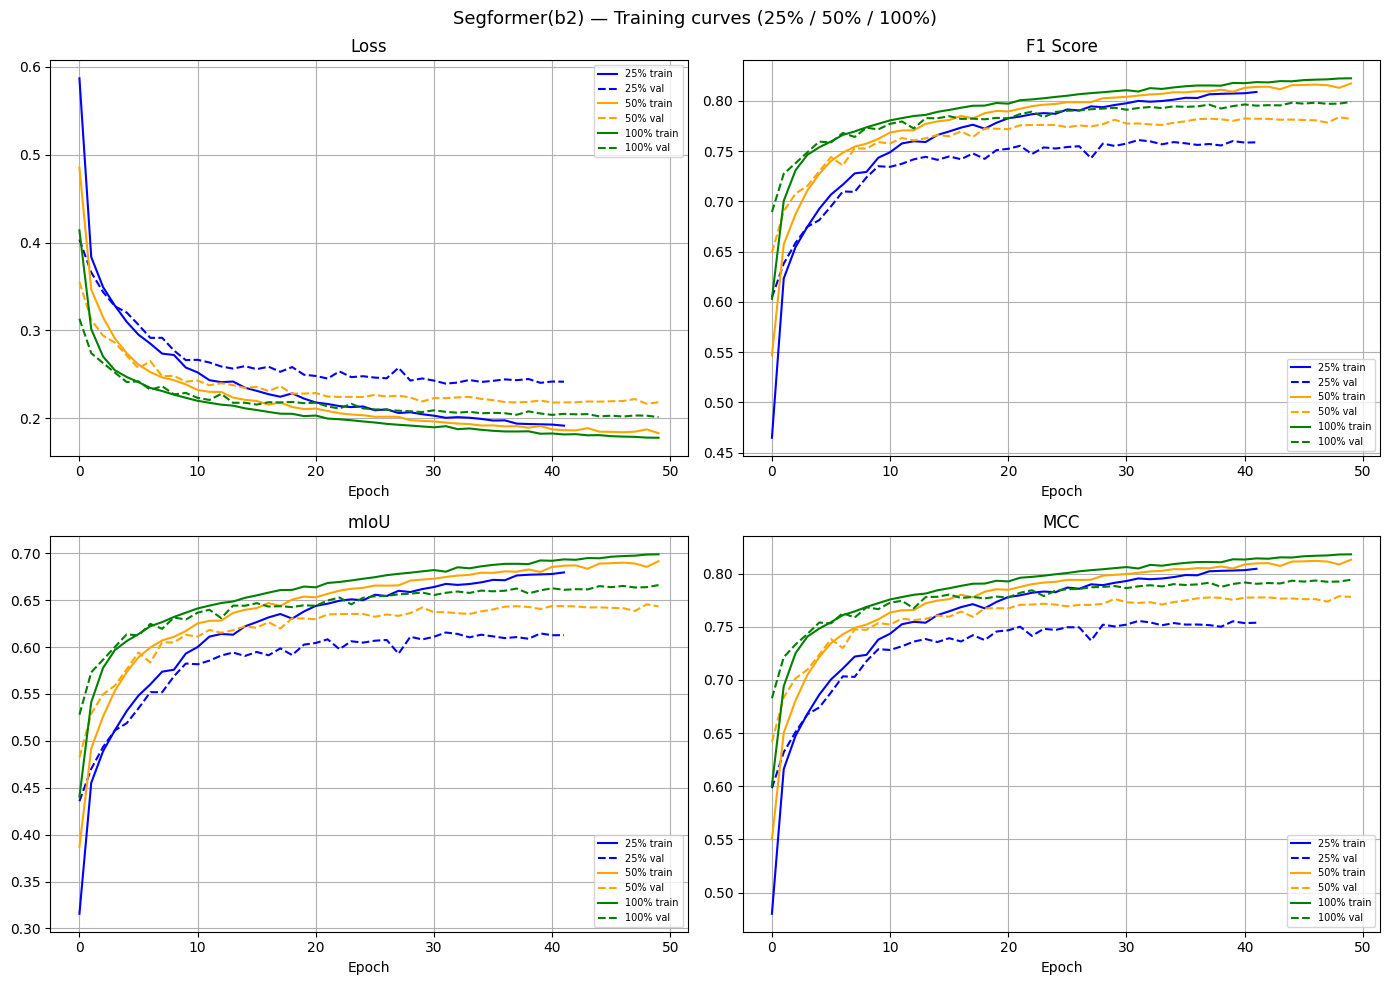

In [16]:
import matplotlib.pyplot as plt

all_histories = {'25%': history_25, '50%': history_50, '100%': history_100}
titles = ['Loss', 'F1 Score', 'mIoU', 'MCC']
keys   = [('train_loss','val_loss'), ('train_f1','val_f1'),
          ('train_miou','val_miou'), ('train_mcc','val_mcc')]
colors = {'25%':'blue', '50%':'orange', '100%':'green'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, title, (tk, vk) in zip(axes, titles, keys):
    for pct, hist in all_histories.items():
        c = colors[pct]
        ax.plot(hist[tk], color=c, linestyle='-',  label=f'{pct} train')
        ax.plot(hist[vk], color=c, linestyle='--', label=f'{pct} val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('Segformer(b2) — Training curves (25% / 50% / 100%)', fontsize=13)
plt.tight_layout()
plt.show()

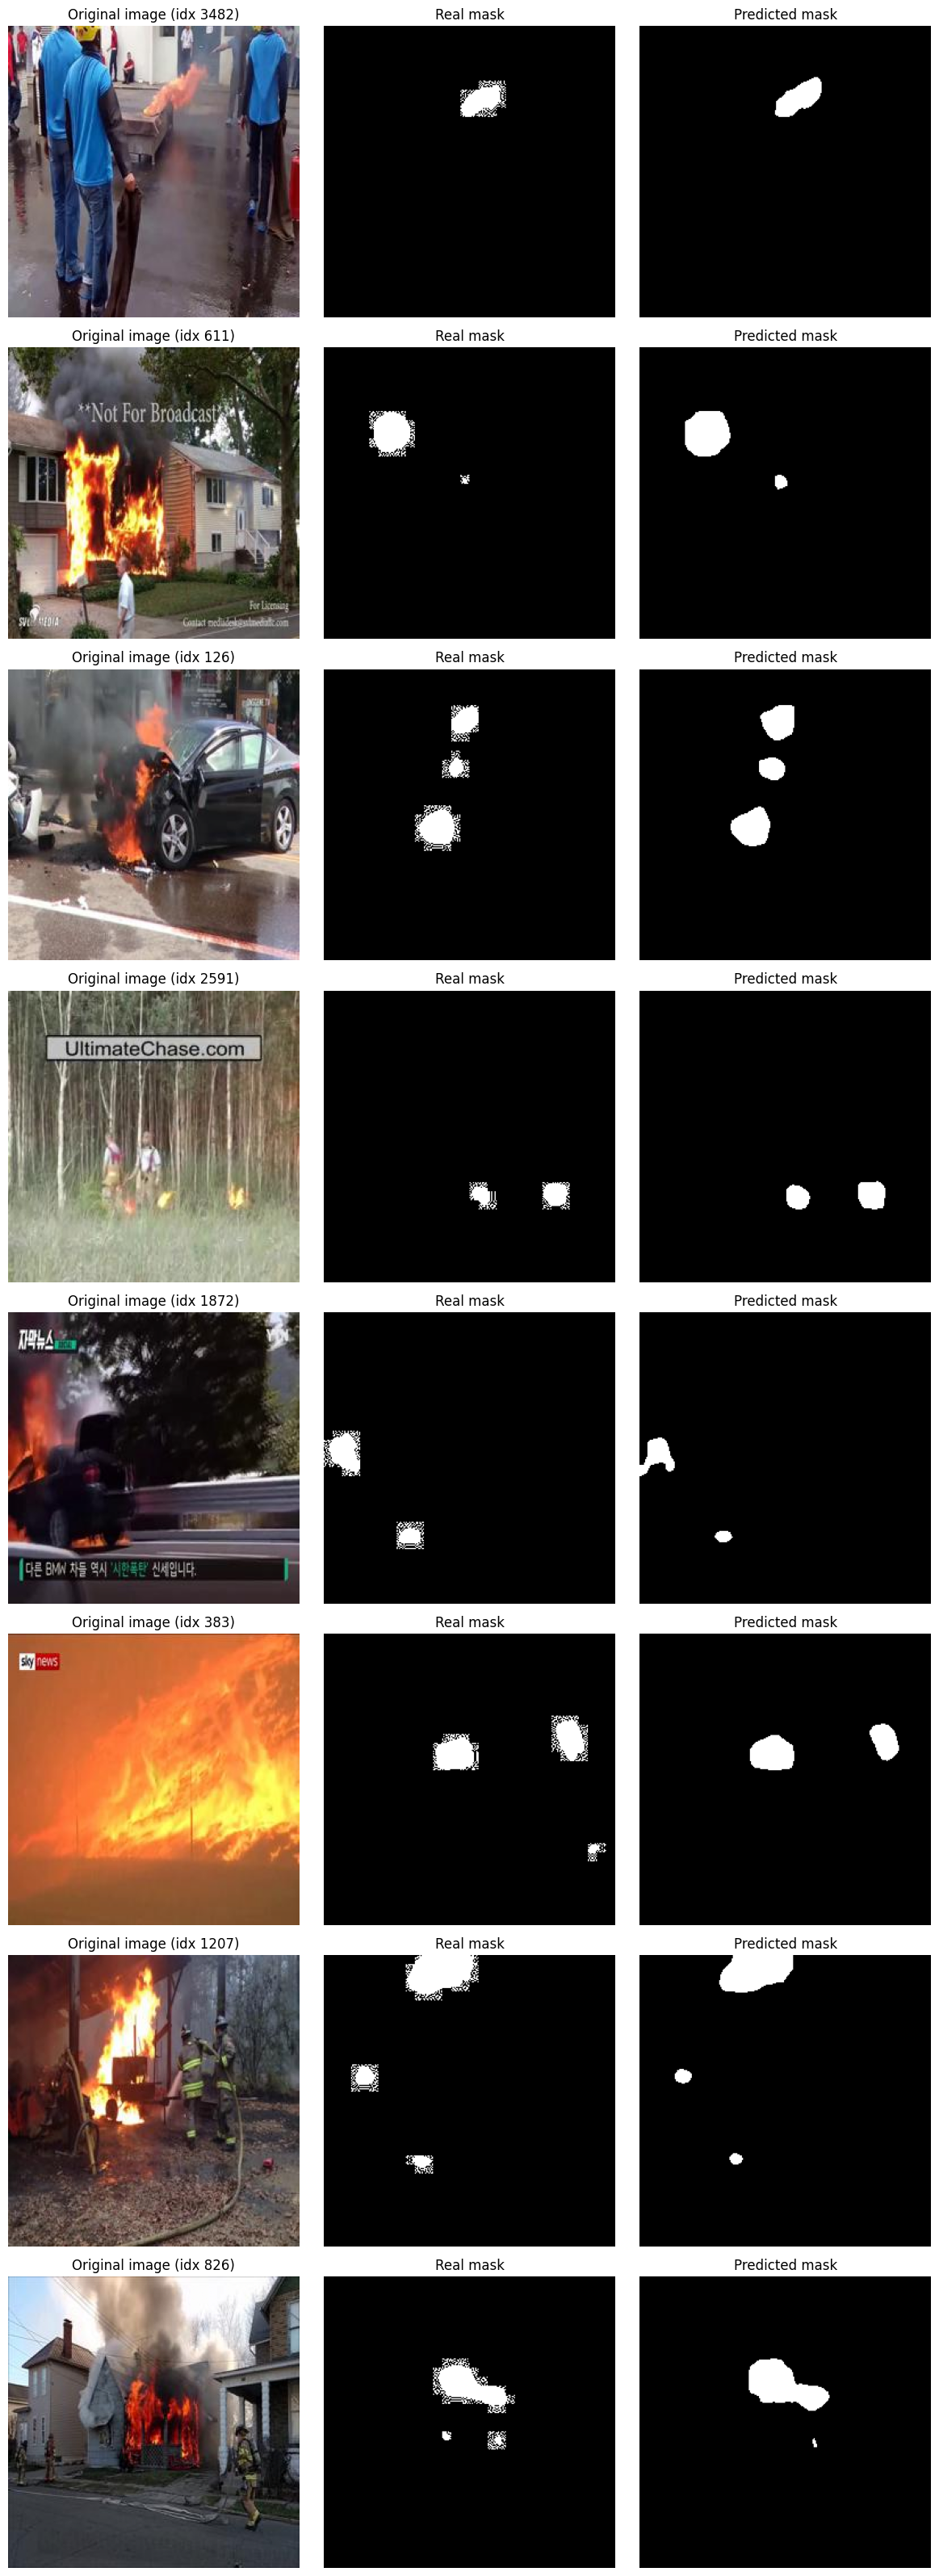

In [18]:
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F

model_100.eval()

num_imgs = 8
test_dataset   = test_loader_100.dataset
random_indices = random.sample(range(len(test_dataset)), num_imgs)

images_list, masks_list = [], []
for idx in random_indices:
    img, mask = test_dataset[idx]
    images_list.append(img)
    masks_list.append(mask)

images = torch.stack(images_list).to(device)
masks  = torch.stack(masks_list)

with torch.no_grad():
    outputs = model_100(pixel_values=images)
    logits  = outputs.logits                          # (B, 1, H/4, W/4)
    logits  = F.interpolate(                          # upsample a tamaño original
        logits,
        size=images.shape[-2:],
        mode="bilinear",
        align_corners=False
    )
    preds = torch.sigmoid(logits)
    preds = (preds > 0.5).float()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(num_imgs, 3, figsize=(12, num_imgs * 4))

for i in range(num_imgs):
    img       = images[i].cpu() * std + mean
    img       = img.permute(1, 2, 0).clamp(0, 1)
    mask_real = masks[i].cpu().squeeze()
    mask_pred = preds[i].cpu().squeeze()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original image (idx {random_indices[i]})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_real, cmap="gray")
    axes[i, 1].set_title("Real mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mask_pred, cmap="gray")
    axes[i, 2].set_title("Predicted mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()